正在扫描文件夹：C:\Users\fire\all2 ...
共发现 76 个 CSV 文件，准备开始合并读取...
合并完成！总数据量: 323598 行
正在清洗数值字段并构造基础特征...
去除疑似买粉后数据量: 205677
合并后总共有 205677 条，为了防止 TF-IDF 炸内存，随机抽取 25000 条进行信息含量分析...
开始分词...
计算标题匹配度(title_match)...
计算TF-IDF及信息密度(info_density)...
正在生成可视化图表...


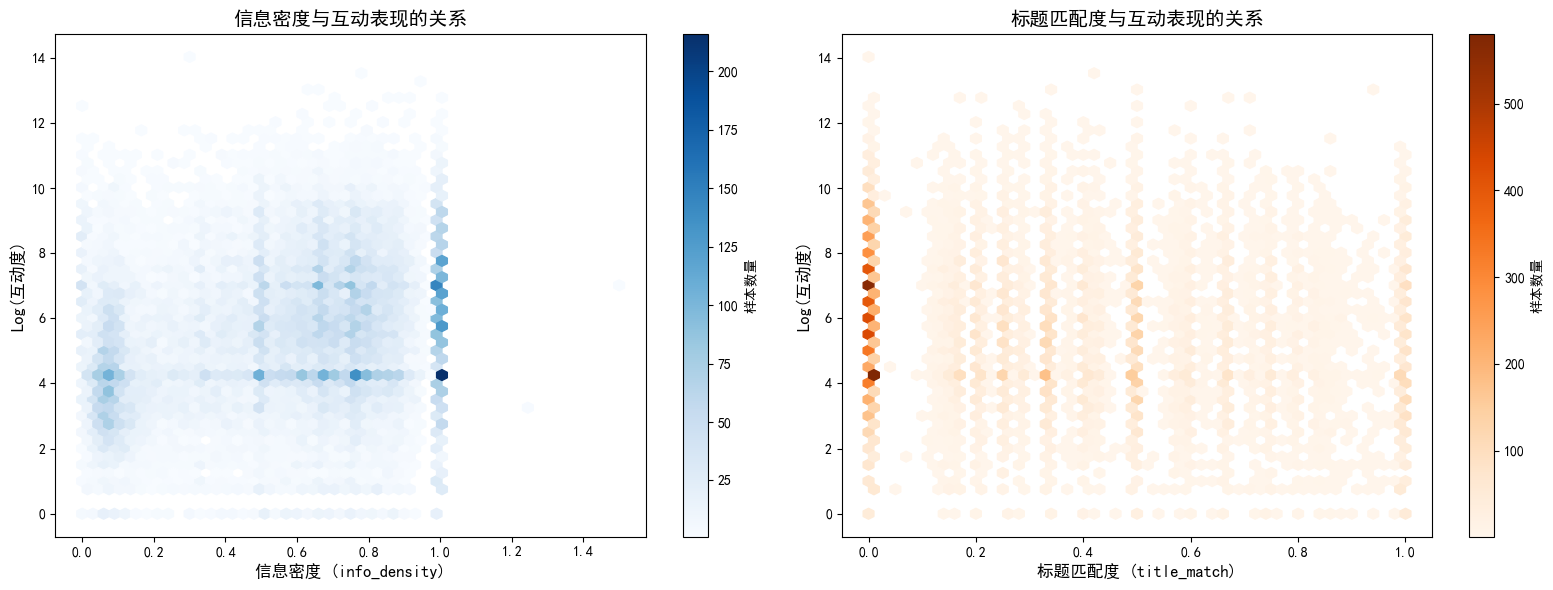

开始进行 OLS 回归分析...
数据量过大，随机抽取 20000 条进行回归分析...
构建回归模型...

================== OLS 回归结果 ==================
                            OLS Regression Results                            
Dep. Variable:         engagement_log   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     259.7
Date:                Thu, 14 May 2026   Prob (F-statistic):          4.24e-321
Time:                        23:26:00   Log-Likelihood:                -43857.
No. Observations:               20000   AIC:                         8.773e+04
Df Residuals:                   19993   BIC:                         8.778e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [3]:
import pandas as pd
import numpy as np
import jieba
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 数据预处理与分词
# ==========================================
def stop_words_list():
    return ['的', '了', '和', '是', '就', '都', '而', '及', '与', '这', '那', '被', '在', '给']

def tokenize(text):
    if not isinstance(text, str):
        return []
    words = jieba.lcut(text)
    stopwords = stop_words_list()
    return [w for w in words if w not in stopwords and len(w.strip()) > 1]

def process_text_features(df):
    """提取所需的文本特征并计算指标"""
    print("开始分词...")
    df['title_tokens'] = df['文案（标题）'].apply(tokenize)
    df['content_tokens'] = df['文案（正文）'].apply(tokenize)
    df['content_joined'] = df['content_tokens'].apply(lambda x: ' '.join(x))

    # 标题匹配度
    print("计算标题匹配度(title_match)...")
    def calc_title_match(row):
        title_set = set(row['title_tokens'])
        content_set = set(row['content_tokens'])
        if len(title_set) == 0:
            return 0
        intersect = title_set.intersection(content_set)
        return len(intersect) / len(title_set)

    df['title_match'] = df.apply(calc_title_match, axis=1)

    # 信息密度
    print("计算TF-IDF及信息密度(info_density)...")
    vectorizer = TfidfVectorizer(max_features=10000, min_df=5)
    tfidf_matrix = vectorizer.fit_transform(df['content_joined'])

    THRESHOLD = 0.1
    info_densities = []
    for i in range(tfidf_matrix.shape[0]):
        row_data = tfidf_matrix.getrow(i).data
        if len(row_data) == 0:
            info_densities.append(0)
            continue
        high_weight_count = np.sum(row_data > THRESHOLD)
        total_words = len(df['content_tokens'].iloc[i])
        if total_words == 0:
            info_densities.append(0)
        else:
            info_densities.append(high_weight_count / total_words)
    df['info_density'] = info_densities
    return df

# ==========================================
# 2. 可视化分析
# ==========================================
def plot_info_value_analysis(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    hb1 = axes[0].hexbin(df['info_density'], df['engagement_log'],
                         gridsize=50, cmap='Blues', mincnt=1)
    axes[0].set_title('信息密度与互动表现的关系', fontsize=14)
    axes[0].set_xlabel('信息密度 (info_density)', fontsize=12)
    axes[0].set_ylabel('Log(互动度)', fontsize=12)
    fig.colorbar(hb1, ax=axes[0], label='样本数量')

    hb2 = axes[1].hexbin(df['title_match'], df['engagement_log'],
                         gridsize=50, cmap='Oranges', mincnt=1)
    axes[1].set_title('标题匹配度与互动表现的关系', fontsize=14)
    axes[1].set_xlabel('标题匹配度 (title_match)', fontsize=12)
    axes[1].set_ylabel('Log(互动度)', fontsize=12)
    fig.colorbar(hb2, ax=axes[1], label='样本数量')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 多元回归分析 (OLS) - 修正多重共线性
# ==========================================
def perform_ols_regression(df, sample_n=20000):
    if len(df) > sample_n:
        print(f"数据量过大，随机抽取 {sample_n} 条进行回归分析...")
        df_reg = df.sample(sample_n, random_state=42).copy()
    else:
        df_reg = df.copy()

    print("构建回归模型...")

    # ---------- 标准化所有连续自变量 ----------
    from sklearn.preprocessing import StandardScaler

    # 需要标准化的列（排除因变量和平方项）
    continuous_cols = ['content_len', 'emotion_strength', 'emotion_extreme', 
                       'info_density', 'title_match']
    scaler = StandardScaler()
    df_reg[continuous_cols] = scaler.fit_transform(df_reg[continuous_cols])

    # 标准化后的平方项（因为标准化后均值为0，平方项就是 (standardized_len)^2）
    df_reg['content_len_sq'] = df_reg['content_len'] ** 2

    # 回归公式
    formula = (
        "engagement_log ~ content_len + content_len_sq + "
        "emotion_strength + emotion_extreme + "
        "info_density + title_match"
    )

    model = smf.ols(formula=formula, data=df_reg).fit()
    print("\n================== OLS 回归结果 ==================")
    print(model.summary())

    # ---------- 多重共线性诊断（VIF） ----------
    print("\n================== 多重共线性诊断 (VIF) ==================")
    X = df_reg[['content_len', 'content_len_sq', 'emotion_strength',
                'emotion_extreme', 'info_density', 'title_match']]
    X = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif_data)

    return model

# ==========================================
# 🚀 主执行流程
# ==========================================
if __name__ == "__main__":
    import os
    import glob

    folder_path = r"C:\Users\fire\all2"
    print(f"正在扫描文件夹：{folder_path} ...")

    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not all_files:
        raise ValueError(f"在 {folder_path} 下没有找到任何 CSV 文件，请检查路径。")

    print(f"共发现 {len(all_files)} 个 CSV 文件，准备开始合并读取...")

    df_list = []
    for file in all_files:
        try:
            temp_df = pd.read_csv(file)
            df_list.append(temp_df)
        except Exception as e:
            print(f"读取文件 '{file}' 时跳过。原因: {e}")

    df = pd.concat(df_list, ignore_index=True)
    print(f"合并完成！总数据量: {len(df)} 行")

    # 丢弃正文为空的数据
    df.dropna(subset=['文案（正文）'], inplace=True)

    # ==========================================
    # 2. 数据清洗与前置特征构造
    # ==========================================
    print("正在清洗数值字段并构造基础特征...")

    df['文案（标题）'] = df['文案（标题）'].astype(str).replace('nan', '')
    df['文案（正文）'] = df['文案（正文）'].astype(str).replace('nan', '')

    # ---------- 列名映射：使用实际列名 ----------
    df['likes'] = pd.to_numeric(df['相对准确点赞数'], errors='coerce')
    df['favs']   = pd.to_numeric(df['相对准确收藏数'], errors='coerce')
    df['comments'] = pd.to_numeric(df['相对准确评论数'], errors='coerce')
    df['fans']   = pd.to_numeric(df['相对准确粉丝数'], errors='coerce')

    # 删除关键互动列缺失的行
    df = df.dropna(subset=['likes', 'comments', 'favs'])

    # 计算互动指标
    df['engagement'] = df['likes'] + df['favs'] + 4 * df['comments']
    df['engagement_log'] = np.log1p(df['engagement'])

    # ---------- 买粉过滤 ----------
    df['fans'] = df['fans'].replace(0, np.nan)  # 避免除零
    df['engagement_rate'] = df['engagement'] / df['fans']

    fan_threshold = df['fans'].quantile(0.9)
    df = df[~(
        (df['fans'] > fan_threshold) &
        (df['engagement_rate'] < 0.01)
    )]
    print("去除疑似买粉后数据量:", len(df))

    # 计算文本长度
    df['content_len'] = df['文案（正文）'].apply(len)

    # 计算情绪特征
    if '情感预测' in df.columns:
        df['emotion_strength'] = pd.to_numeric(df['情感预测'], errors='coerce')
        df['emotion_strength'] = df['emotion_strength'].fillna(0.5)
        df['emotion_extreme'] = (df['emotion_strength'] - 0.5).abs()
    else:
        print("警告: 未找到'情感预测'列，设为默认值...")
        df['emotion_strength'] = 0.5
        df['emotion_extreme'] = 0.0

    # ==========================================
    # 3. 核心：提取信息价值模块特征
    # ==========================================
    max_sample = 25000
    if len(df) > max_sample:
        print(f"合并后总共有 {len(df)} 条，为了防止 TF-IDF 炸内存，随机抽取 {max_sample} 条进行信息含量分析...")
        df_work = df.sample(n=max_sample, random_state=42).copy()
    else:
        df_work = df.copy()

    df_processed = process_text_features(df_work)

    # ==========================================
    # 4. 可视化与 OLS 回归
    # ==========================================
    print("正在生成可视化图表...")
    plot_info_value_analysis(df_processed)

    print("开始进行 OLS 回归分析...")
    model = perform_ols_regression(df_processed, sample_n=20000)